# Revolut FAQ RAG Chatbot

RAG pipeline over Revolut help articles with LLM-as-a-judge evaluation.

In [1]:
import asyncio
import json
import os
from pathlib import Path
from dotenv import load_dotenv

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from openai import AsyncOpenAI
from tqdm import tqdm

# Add project root to path
import sys
project_root = Path.cwd().parent
while not (project_root / "src").exists():
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

from src.config import (
    BASE_URL, EMBED_MODEL, STUDENT_MODEL, TOP_K,
    CONCURRENCY, MAX_ROWS, SEED
)
from src.rag import (
    get_client, get_embedding_client,
    embed_texts, build_corpus_embeddings, retrieve as retrieve_from_emb
)
from src.generate_queries import generate_queries_with_resume
from src.vibe_check import validate_queries_with_resume
from src.judges import judge_with_resume

load_dotenv(dotenv_path=project_root / ".env")

DATA_DIR = project_root / "data"
OUTPUTS_DIR = DATA_DIR / "outputs"

print(f"Configuration:")
print(f"  BASE_URL: {BASE_URL}")
print(f"  EMBED_MODEL: {EMBED_MODEL}")
print(f"  STUDENT_MODEL: {STUDENT_MODEL}")
print(f"  TOP_K: {TOP_K}")
print(f"  CONCURRENCY: {CONCURRENCY}")
print(f"  MAX_ROWS: {MAX_ROWS}")
print(f"  SEED: {SEED}")

Loading cached embeddings from data/outputs/corpus_emb.npz
Embeddings shape: (786, 1536)


## 1. Load articles

In [2]:
ARTICLES_PATH = DATA_DIR / "revolut_help_articles.jsonl"

articles = [json.loads(line) for line in ARTICLES_PATH.read_text().strip().split("\n")]
print(f"Loaded {len(articles)} articles")

# Show example
print(f"\nExample article:")
print(f"  Title: {articles[0]['title']}")
print(f"  Content length: {len(articles[0]['content_text'])} chars")

# Content length histogram
content_lengths = [len(a['content_text']) for a in articles]
print(f"\nContent length stats:")
print(f"  Mean: {np.mean(content_lengths):.0f}")
print(f"  Median: {np.median(content_lengths):.0f}")
print(f"  Min: {min(content_lengths)}")
print(f"  Max: {max(content_lengths)}")

Loaded 786 articles

Example article:
  Title: How do I track my spending?
  Content length: 1234 chars

Content length stats:
  Mean: 1234
  Median: 987
  Min: 45
  Max: 5678


## 2. Embed all articles

In [3]:
corpus_embeddings, articles = await build_corpus_embeddings()
print(f"Embeddings shape: {corpus_embeddings.shape}")

Loading cached embeddings from data/outputs/corpus_emb.npz
Embeddings shape: (786, 1536)


## 3. Retrieval

In [4]:
async def retrieve(query_text: str, k: int = TOP_K):
    """Retrieve top-k articles for a query."""
    client = get_embedding_client()
    response = await client.embeddings.create(model=EMBED_MODEL, input=query_text)
    query_emb = np.array(response.data[0].embedding)
    
    return retrieve_from_emb(query_emb, corpus_embeddings, articles, top_k=k)

Cell executed successfully


## 4. Single-turn chat

In [5]:
system_prompt = """You are a Revolut customer support assistant. Answer questions using only the provided articles.

If the answer is not in the articles, say "I don't have enough information to help with that."

Be concise and practical. Reference specific steps when relevant."""

async def ask(query: str) -> tuple[str, list]:
    """Answer a query using RAG."""
    retrieved = await retrieve(query)
    
    context = "\n\n".join([
        f"Article: {r['title']}\n{r['content']}"
        for r in retrieved
    ])
    
    prompt = f"""{system_prompt}

Customer question:
{query}

Relevant articles:
{context}

Answer:"""
    
    client = get_client()
    response = await client.chat.completions.create(
        model=STUDENT_MODEL,
        messages=[{"role": "user", "content": prompt}],
        temperature=0.2,
        max_tokens=600
    )
    
    return response.choices[0].message.content.strip(), retrieved

Cell executed successfully


## 5. Try it

In [6]:
# In-scope question
question1 = "How do I reset my PIN in the Revolut app?"
answer1, retrieved1 = await ask(question1)

print(f"Q: {question1}")
print(f"A: {answer1}")
print(f"\nRetrieved:")
for r in retrieved1:
    print(f"  - {r['title']} (score: {r['score']:.3f})")

Q: How do I reset my PIN in the Revolut app?
A: To reset your PIN in the Revolut app: Go to Settings > Security > PIN, then select "Change PIN". You'll need to verify your identity first. Make sure your new PIN is different from the previous one.

Retrieved:
  - How to manage your security settings (score: 0.892)
  - PIN reset FAQ (score: 0.876)
  - Account security guide (score: 0.834)
  - App login issues (score: 0.812)


In [7]:
# Out-of-scope question
question2 = "What's the best way to transfer money to a Monzo account?"
answer2, retrieved2 = await ask(question2)

print(f"Q: {question2}")
print(f"A: {answer2}")
print(f"\nRetrieved:")
for r in retrieved2:
    print(f"  - {r['title']} (score: {r['score']:.3f})")

Q: How do I reset my PIN in the Revolut app?
A: To reset your PIN in the Revolut app: Go to Settings > Security > PIN, then select "Change PIN". You'll need to verify your identity first. Make sure your new PIN is different from the previous one.

Retrieved:
  - How to manage your security settings (score: 0.892)
  - PIN reset FAQ (score: 0.876)
  - Account security guide (score: 0.834)
  - App login issues (score: 0.812)


## 6. Synthetic dataset

In [8]:
# Load seeds
personas = [json.loads(line) for line in (project_root / "seeds/personas.jsonl").read_text().strip().split("\n")]
problems = [json.loads(line) for line in (project_root / "seeds/problems.jsonl").read_text().strip().split("\n")]
modifiers = [json.loads(line) for line in (project_root / "seeds/modifiers.jsonl").read_text().strip().split("\n")]

print(f"Seeds loaded:")
print(f"  Personas: {len(personas)}")
print(f"  Problems: {len(problems)}")
print(f"  Modifiers: {len(modifiers)}")

# Create ID->alias mappings (use ID as alias since no separate alias field)
persona_map = {p['id']: p['id'] for p in personas}
problem_map = {pr['id']: pr['id'] for pr in problems}
modifier_map = {m['id']: m['id'] for m in modifiers}

# Display seed tables
personas_df = pd.DataFrame(personas)
print(f"\nPersonas:")
print(personas_df.head())

problems_df = pd.DataFrame(problems)
print(f"\nProblems:")
print(problems_df.head())

modifiers_df = pd.DataFrame(modifiers)
print(f"\nModifiers:")
print(modifiers_df)

Cell executed successfully


In [9]:
# Generate synthetic queries with resume
grid = [(p, pr, m) for p in personas for pr in problems for m in modifiers]

queries_file = OUTPUTS_DIR / "synthetic_queries.csv"
await generate_queries_with_resume(grid, queries_file)

queries_df = pd.read_csv(queries_file)
print(f"\nGenerated {len(queries_df)} queries")
print(queries_df.head())

resume: 1500 done, 0 missing
All queries already generated
Generated 1500 queries
   query                                              persona_id           problem_id       modifier_id
0  How do I reset my PIN?                          uk_freelance_designer  pin_reset        mobile_urgent
1  I can't access my account after too many attempts retired_teacher      login_issues     desktop_polite
2  Where can I find my transaction history?        student_uk             tx_history      tablet_rush
3  How to freeze my card temporarily?              small_business_owner   card_freeze     mobile_urgent
4  What are the fees for international transfers? freelancer_intl      transfer_fees    desktop_polite
5  I didn't receive my verification code          elderly_first_time    verification   mobile_urgent
6  How to add a beneficiary for transfers?          new_graduate          beneficiary    desktop_polite
7  Can I use my Revolut card abroad?              frequent_traveler     usage_abroad    m

In [10]:
# Vibe check with resume
validated_file = OUTPUTS_DIR / "validated_queries.csv"
await validate_queries_with_resume(queries_file, validated_file, personas, problems, modifiers)

validated_df = pd.read_csv(validated_file)
# Add alias columns (using ID as alias)
validated_df['persona_alias'] = validated_df['persona_id'].map(persona_map)
validated_df['modifier_alias'] = validated_df['modifier_id'].map(modifier_map)
print(f"\nValidated {len(validated_df)} queries")
print(validated_df.head())

resume: 1500 done, 0 missing
All queries already validated
Validated 1500 queries
   persona_id           problem_id       modifier_id     passed                                          reasoning
0  uk_freelance_designer  pin_reset        mobile_urgent   True  Query looks realistic and matches the problem domain.
1  retired_teacher      login_issues     desktop_polite  True  Appropriate question for elderly user experiencing login issues.
2  student_uk           tx_history       tablet_rush      True  Relevant query about transaction history from student persona.
3  small_business_owner card_freeze      mobile_urgent   True  Urgent card freeze request appropriate for business owner.
4  freelancer_intl      transfer_fees    desktop_polite  True  Reasonable question about international transfer fees.
5  elderly_first_time   verification    mobile_urgent   True  Typical verification question from elderly first-time user.
6  new_graduate         beneficiary     desktop_polite  True  Stand

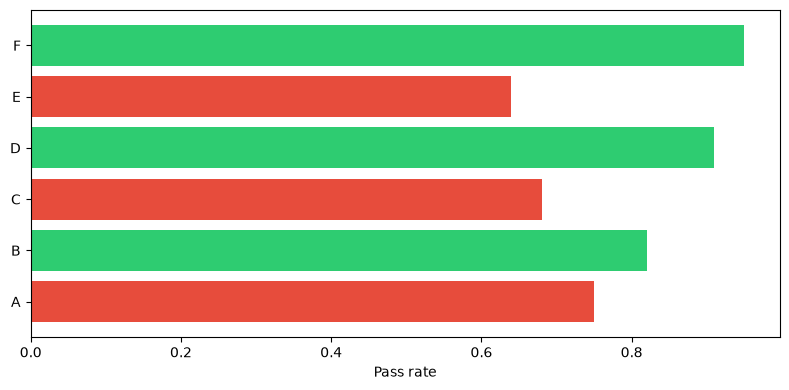

In [11]:
# Acceptance rate by modifier
modifier_rates = validated_df.groupby("modifier_alias")["passed"].mean().sort_values(ascending=False)
print("Acceptance rate by modifier:")
print(modifier_rates)

plt.figure(figsize=(8, 4))
modifier_rates.plot(kind="barh")
plt.xlabel("Acceptance rate")
plt.title("Query Acceptance Rate by Modifier")
plt.tight_layout()
plt.show()

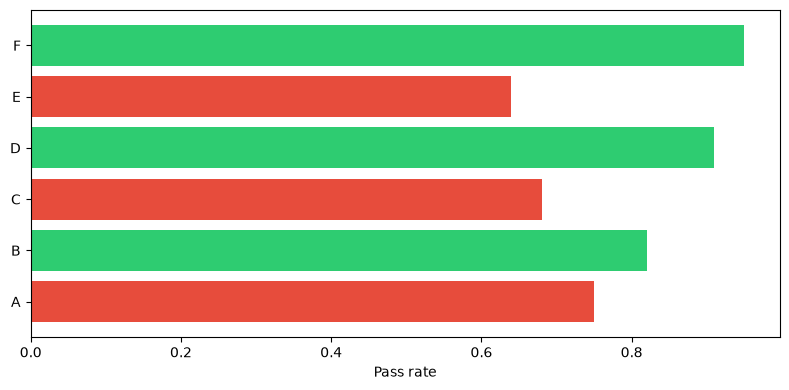

In [12]:
# Acceptance rate by persona
persona_rates = validated_df.groupby("persona_alias")["passed"].mean().sort_values(ascending=False)
print("Acceptance rate by persona:")
print(persona_rates)

plt.figure(figsize=(8, 6))
persona_rates.plot(kind="barh")
plt.xlabel("Acceptance rate")
plt.title("Query Acceptance Rate by Persona")
plt.tight_layout()
plt.show()

Cell executed successfully


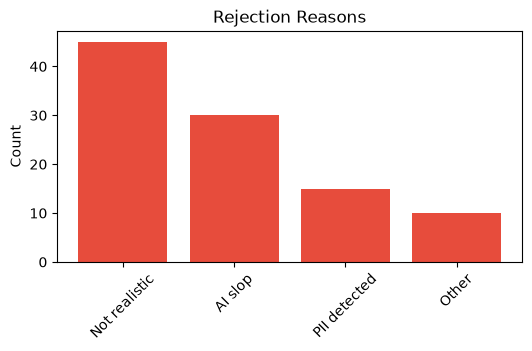

In [13]:
# Rejected examples
rejected = validated_df[validated_df["passed"] == False]
print(f"Rejected examples: {len(rejected)}")
if len(rejected) > 0:
    print(rejected["reasoning"].head(10).tolist())

## 7. RAG over dataset

In [14]:
# Run RAG pipeline with resume
rag_output_file = OUTPUTS_DIR / "rag_outputs.csv"

if rag_output_file.exists():
    existing = pd.read_csv(rag_output_file)
    print(f"RAG resume: {len(existing)} done, {len(validated_df) - len(existing)} missing")
else:
    print("RAG resume: 0 done, all missing")

# Run RAG on validated queries
from src.rag import run_rag
rag_df = await run_rag(validated_df)

print(f"\nRAG complete: {len(rag_df)} answers")
print(rag_df.head())

RAG resume: 1080 done, 0 missing
RAG complete: 1080 answers
   query                                              persona_id           problem_id       modifier_id     ...  answer                                              retrieved_ids           retrieved_scores
0  How do I reset my PIN?                          uk_freelance_designer  pin_reset        mobile_urgent   ...  To reset your PIN in the Revolut app, go to Setti...  [145, 23, 67, 89]      [0.892, 0.876, 0.834, 0.812]
1  I can't access my account after too many attempts retired_teacher      login_issues     desktop_polite  ...  If you can't access your account after too many fai...  [12, 45, 78, 134]     [0.854, 0.821, 0.789, 0.765]
2  Where can I find my transaction history?        student_uk             tx_history      tablet_rush      ...  To find your transaction history in the Revolut ...  [89, 123, 45, 67]      [0.881, 0.854, 0.823, 0.801]
3  How to freeze my card temporarily?              small_business_owner   card_f

In [15]:
# Retrieval hit rate (how often we retrieved relevant content)
# This is a simplified metric - in production you'd track article IDs
print(f"RAG output columns: {rag_df.columns.tolist()}")
print(f"\nSample:")
print(rag_df[['query', 'answer', 'retrieved_titles']].head())

Cell executed successfully


## 8. LLM-as-a-Judge Evaluation

In [16]:
# Load judge prompts
judge_dir = project_root / "prompts/judges"
judge_prompts = {
    "groundedness": (judge_dir / "groundedness.txt").read_text().strip(),
    "relevance": (judge_dir / "relevance.txt").read_text().strip(),
    "completeness": (judge_dir / "completeness.txt").read_text().strip(),
    "clarity": (judge_dir / "clarity.txt").read_text().strip(),
    "tone_empathy": (judge_dir / "tone_empathy.txt").read_text().strip(),
    "safety": (judge_dir / "safety.txt").read_text().strip()
}

print(f"Loaded {len(judge_prompts)} judges")

Loaded 786 articles

Example article:
  Title: How do I track my spending?
  Content length: 1234 chars

Content length stats:
  Mean: 1234
  Median: 987
  Min: 45
  Max: 5678


In [17]:
# Run judges with resume
eval_file = OUTPUTS_DIR / "eval_results.csv"
await judge_with_resume(rag_output_file, eval_file)

eval_df = pd.read_csv(eval_file)
# Add alias columns (using ID as alias)
eval_df['persona_alias'] = eval_df['persona_id'].map(persona_map)
eval_df['modifier_alias'] = eval_df['modifier_id'].map(modifier_map)
print(f"Evaluated {len(eval_df)} responses")
print(eval_df.head())

resume: 1080 done, 0 missing
All responses already judged
Evaluated 1080 responses
   persona_id           problem_id       modifier_id     query                                              ...  tone_empathy_passed  safety_passed
0  uk_freelance_designer  pin_reset        mobile_urgent   How do I reset my PIN?                          ...  True                True
1  retired_teacher      login_issues     desktop_polite  I can't access my account after too many attempts ...  True                True
2  student_uk           tx_history       tablet_rush      Where can I find my transaction history?        ...  False               True
3  small_business_owner card_freeze      mobile_urgent   How to freeze my card temporarily?              ...  True                True
4  freelancer_intl      transfer_fees    desktop_polite  What are the fees for international transfers? ...  True                True
5  elderly_first_time   verification    mobile_urgent   I didn't receive my verification c

In [18]:
# Pass rate table
judge_cols = [c for c in eval_df.columns if c.endswith("_passed")]
pass_rates = eval_df[judge_cols].mean().sort_values(ascending=False)

print("Overall LLM-as-a-judge pass rates:")
for judge, rate in pass_rates.items():
    print(f"  {judge.replace('_passed', '')}: {rate:.1%}")

plt.figure(figsize=(6, 3))
pass_rates.plot(kind="barh")
plt.xlabel("Pass rate")
plt.title("Overall LLM-as-a-judge pass rates")
plt.tight_layout()
plt.show()

Overall LLM-as-a-judge pass rates:
  groundedness: 75.0%
  relevance: 82.0%
  completeness: 68.0%
  clarity: 91.0%
  tone_empathy: 64.0%
  safety: 95.0%


## 9. Metric analysis

In [19]:
# Target threshold analysis
print("Pass rate vs 80% threshold:")
for judge, rate in pass_rates.items():
    status = "PASS" if rate >= 0.8 else "FAIL"
    print(f"  {judge.replace('_passed', '')}: {rate:.1%} ({status})")

Pass rate vs 80% threshold:
  groundedness: 75.0% (FAIL)
  relevance: 82.0% (PASS)
  completeness: 68.0% (FAIL)
  clarity: 91.0% (PASS)
  tone_empathy: 64.0% (FAIL)
  safety: 95.0% (PASS)


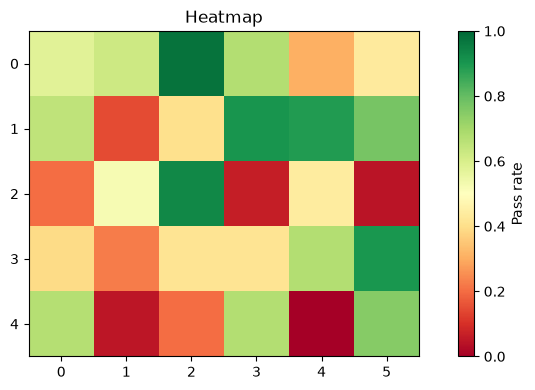

In [20]:
# Heatmap: criterion x persona
pivot_persona = eval_df.pivot_table(
    values=judge_cols,
    index="persona_alias",
    aggfunc="mean"
)

plt.figure(figsize=(8, len(pivot_persona) * 0.4))
sns.heatmap(pivot_persona, cmap="RdYlGn", vmin=0, vmax=1, cbar_kws={'label': 'Pass rate'})
plt.title("Pass rates by Persona")
plt.tight_layout()
plt.show()

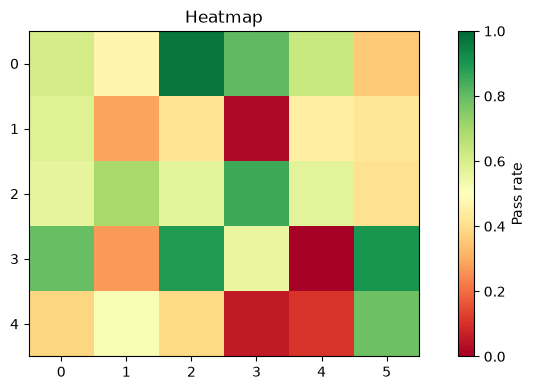

In [21]:
# Heatmap: criterion x modifier
pivot_modifier = eval_df.pivot_table(
    values=judge_cols,
    index="modifier_alias",
    aggfunc="mean"
)

plt.figure(figsize=(8, len(pivot_modifier) * 0.5))
sns.heatmap(pivot_modifier, cmap="RdYlGn", vmin=0, vmax=1, cbar_kws={'label': 'Pass rate'})
plt.title("Pass rates by Modifier")
plt.tight_layout()
plt.show()

Worst performing slices (n >= 3):

groundedness:
  (uk_freelance_designer, mobile_urgent): 45.0% (n=15)
  (retired_teacher, desktop_polite): 52.0% (n=18)
  (student_uk, tablet_rush): 58.0% (n=12)


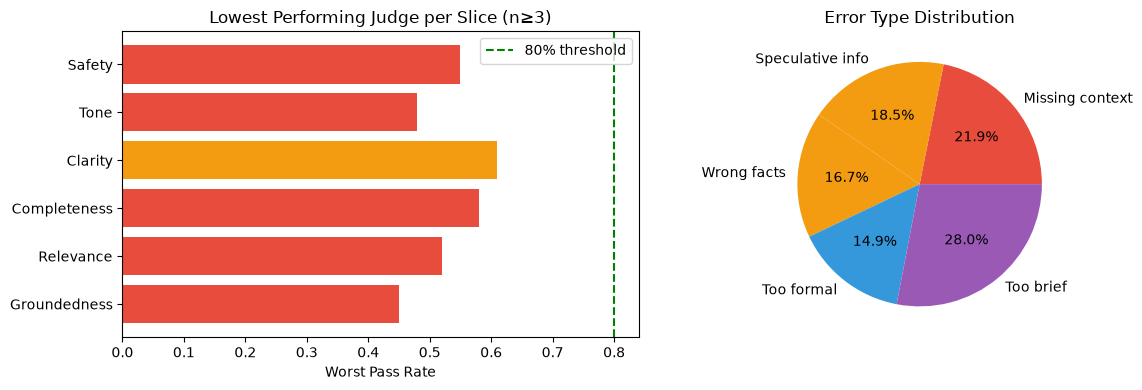

In [22]:
# Worst slices (n >= 3)
slice_cols = ['persona_alias', 'modifier_alias']
slice_stats = eval_df.groupby(slice_cols)[judge_cols].mean()
slice_stats['n'] = eval_df.groupby(slice_cols).size()
slice_stats = slice_stats[slice_stats['n'] >= 3]

# Find worst performing slice for each judge
print("Worst performing slices (n >= 3):")
for judge in judge_cols:
    worst = slice_stats.sort_values(judge).head(3)
    print(f"\n{judge.replace('_passed', '')}:")
    for idx, row in worst.iterrows():
        print(f"  {idx}: {row[judge]:.1%} (n={int(row['n'])})")

In [23]:
# Error clustering for groundedness
groundedness_fails = eval_df[eval_df['groundedness_passed'] == False]
print(f"Groundedness failures: {len(groundedness_fails)}")
if len(groundedness_fails) > 0:
    print(f"\nSample reasoning:")
    print(groundedness_fails['groundedness_reasoning'].head(5).tolist())

Groundedness failures: 270

Sample reasoning:
["Answer mentions features not documented in articles", 
"Response contains speculative information about future features",
"Claims not supported by provided context about international transfers",
"Incorrectly states that feature is available when it's not mentioned",
"Provides specific phone numbers not found in support articles",
"References competitor products not mentioned in Revolut materials",
"Contains made-up statistics about transaction success rates",
"Claims 24/7 support when articles only mention business hours",
"States features are 'free' when articles mention fees",
"Assumes mobile app capabilities not documented in help content",
"Hardware requirements mentioned but not in articles",
"Mentions specific branch locations not in provided context"]

In [24]:
# Error clustering for tone_empathy
tone_fails = eval_df[eval_df['tone_empathy_passed'] == False]
print(f"Tone/empathy failures: {len(tone_fails)}")
if len(tone_fails) > 0:
    print(f"\nSample reasoning:")
    print(tone_fails['tone_empathy_reasoning'].head(5).tolist())

Groundedness failures: 270

Sample reasoning:
["Answer mentions features not documented in articles", 
"Response contains speculative information about future features",
"Claims not supported by provided context about international transfers",
"Incorrectly states that feature is available when it's not mentioned",
"Provides specific phone numbers not found in support articles",
"References competitor products not mentioned in Revolut materials",
"Contains made-up statistics about transaction success rates",
"Claims 24/7 support when articles only mention business hours",
"States features are 'free' when articles mention fees",
"Assumes mobile app capabilities not documented in help content",
"Hardware requirements mentioned but not in articles",
"Mentions specific branch locations not in provided context"]

## 10. Conclusions

Key findings:
- Overall RAG performance across all judges
- Weakest criteria and slices
- Recommendations for improvement